1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt



In [ ]:
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cpu


Data Preprocessing AND LOADING THEM INTO TENSORS

In [ ]:
try:
    data = pd.read_csv('/content/datset_used.csv')  # Update the path as necessary
except FileNotFoundError:
    raise FileNotFoundError("The file 'Data.csv' was not found. Please ensure the file exists in the specified path.")

# Display the first few rows to verify
print("\nFirst 5 rows of the dataset:")
print(data.head())
print(data.describe())

# Convert 'Type_of_aggregates' Categorical Feature to Numerical Codes
if 'Type_of_aggregates' in data.columns:
    data['Type_of_aggregates'] = data['Type_of_aggregates'].astype('category').cat.codes
else:
    raise ValueError("Column 'Type_of_aggregates' not found in the dataset.")

# Drop Irrelevant Column
if "Design_F'c (Mpa)" in data.columns:
    data = data.drop("Design_F'c (Mpa)", axis=1)
else:
    print("Column 'Design_F'c (Mpa)' not found in the dataset. Proceeding without dropping.")

# Check for missing values
print("\nMissing values in each column:")
print(data.isnull().sum())

# Define Numerical Features for Scaling
numerical_features = ['Curing_age_(days)', 'UPV_(m/s)', 'Er_(ohm-cm)']

# Check if all numerical features exist
for feature in numerical_features:
    if feature not in data.columns:
        raise ValueError(f"Numerical feature '{feature}' not found in the dataset.")

# Initialize Scaler
scaler = StandardScaler()

# Fit and Transform Numerical Features
data[numerical_features] = scaler.fit_transform(data[numerical_features])

# Define Input Features (X) and Target Variable (y)
if 'Cs_(Mpa)' not in data.columns:
    raise ValueError("Target column 'Cs_(Mpa)' not found in the dataset.")
X = data.drop('Cs_(Mpa)', axis=1)
y = data['Cs_(Mpa)']

# Convert All Features to Numeric Format and Handle Missing Values
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
y = pd.to_numeric(y, errors='coerce').fillna(0)

# Split Dataset into Training (70%), Validation (15%), and Test (15%) Sets
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, random_state=42
)  # 0.1765 * 0.85 ≈ 0.15

print(f"\nDataset sizes:")
print(f"Training: {X_train.shape[0]} samples")
print(f"\nTraining_dataset",X_train.describe())
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

# Convert Data to PyTorch Tensors and Move to Device
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1).to(device)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1).to(device)



First 5 rows of the dataset:
  Type_of_aggregates  Curing_age_(days)  Cs_(Mpa)  Er_(ohm-cm)  UPV_(m/s)
0            Rounded                  3    5.2154       5.8654  2440.2989
1            Rounded                  3    5.1528       5.9471  2417.9562
2            Rounded                  3    5.6877       5.9965  2429.9277
3            Rounded                  3    5.1476       5.8751  2435.0202
4            Rounded                  3    5.3406       5.8654  2408.7969
       Curing_age_(days)     Cs_(Mpa)  Er_(ohm-cm)    UPV_(m/s)
count        4420.000000  4420.000000  4420.000000  4420.000000
mean           40.443439    31.193113     6.760444  3808.959267
std            33.308785     9.588822     2.970590   561.041125
min             3.000000     5.082300     1.831200  2345.981200
25%            14.000000    24.962400     4.639225  3364.670525
50%            28.000000    31.853700     6.070350  3722.880700
75%            60.000000    36.075400     7.461300  4357.101400
max           

In [ ]:
print(X_train.describe())

       Type_of_cement   Brand  Additives  Type_of_aggregates  \
count          3093.0  3093.0     3093.0         3093.000000   
mean              0.0     0.0        0.0            1.071775   
std               0.0     0.0        0.0            0.956706   
min               0.0     0.0        0.0            0.000000   
25%               0.0     0.0        0.0            0.000000   
50%               0.0     0.0        0.0            1.000000   
75%               0.0     0.0        0.0            2.000000   
max               0.0     0.0        0.0            3.000000   

       Curing_age_(days)  Er_(ohm-cm)    UPV_(m/s)  
count        3093.000000  3093.000000  3093.000000  
mean           -0.017770    -0.016573     0.004908  
std             0.990036     0.983710     0.998873  
min            -1.124258    -1.659536    -2.607908  
25%            -0.793978    -0.718371    -0.782961  
50%            -0.373621    -0.235584    -0.140088  
75%             0.587196     0.235958     0.978466  

Define the Neural Network Model

In [ ]:
class ConcreteStrengthANN(nn.Module):
    def __init__(self, input_size, hidden_layer_size=250):
        super(ConcreteStrengthANN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_layer_size)
        self.fc2 = nn.Linear(hidden_layer_size, hidden_layer_size)
        self.fc3 = nn.Linear(hidden_layer_size, hidden_layer_size)
        self.dropout = nn.Dropout(0.1)
        self.fc4 = nn.Linear(hidden_layer_size, 1)
        self.activation1 = nn.Tanh()
        self.activation2 = nn.Identity()  # Identity activation for output layer

    def forward(self, x):
        x = self.activation1(self.fc1(x))
        x = self.dropout(x)
        x = self.activation1(self.fc2(x))
        x = self.dropout(x)
        x = self.activation1(self.fc3(x))
        x = self.dropout(x)
        x = self.activation2(self.fc4(x))
        return x

# Instantiate the Model and Move to Device
input_size = X_train.shape[1]
model = ConcreteStrengthANN(input_size).to(device)
print("\nNeural Network Architecture:")
print(model)



Neural Network Architecture:
ConcreteStrengthANN(
  (fc1): Linear(in_features=4, out_features=250, bias=True)
  (fc2): Linear(in_features=250, out_features=250, bias=True)
  (fc3): Linear(in_features=250, out_features=250, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc4): Linear(in_features=250, out_features=1, bias=True)
  (activation1): Tanh()
  (activation2): Identity()
)


Define Loss Functions

In [ ]:
criterion_data = nn.MSELoss()

# Define Empirical Equation Coefficients
A = 7.2086
B = 1
C = 0.4238
D = 0.7560
F = -0.4272

# Physics-Informed Loss Function Based on the Empirical Equation
def physics_informed_loss(age_scaled, UPV_scaled, ER_scaled, predicted_Cs, scaler):
    """
    Computes the physics-informed loss based on the empirical equation:
    Cs = A * log(age + 1) + C * exp(D * (UPV / 1000)) + F * log(ER)

    Parameters:
    - age_scaled: Scaled age tensor
    - UPV_scaled: Scaled UPV tensor
    - ER_scaled: Scaled ER tensor
    - predicted_Cs: Predicted Cs tensor
    - scaler: Fitted StandardScaler object
    """
    epsilon = 1e-6  # Small value to prevent log(0)

    # Inverse scale the inputs
    age_unscaled = age_scaled * scaler.scale_[0] + scaler.mean_[0]
    UPV_unscaled = UPV_scaled * scaler.scale_[1] + scaler.mean_[1]
    ER_unscaled = ER_scaled * scaler.scale_[2] + scaler.mean_[2]

    # Compute empirical Cs using the unscaled inputs
    empirical_Cs = (
        A * torch.log(age_unscaled + B + epsilon) +
        C * torch.exp(D * (UPV_unscaled / 1000)) +
        F * torch.log(ER_unscaled + epsilon)
    )

    # Compute the Mean Squared Error between predicted and empirical Cs
    loss_phy = torch.mean((predicted_Cs - empirical_Cs) ** 2)
    return loss_phy

# Boundary Loss Function to Enforce Constraints
def boundary_loss(predicted_Cs, UPV_scaled, ER_scaled, age_scaled, scaler):
    """
    Penalizes predictions that fall outside the specified ranges:
    Cs: 0 ≤ Cs ≤ 150
    UPV: 1000 ≤ UPV ≤ 6000
    ER: 10 ≤ ER ≤ 100
    Age: 0 ≤ Age ≤ 1000

    Parameters:
    - predicted_Cs: Predicted Cs tensor
    - UPV_scaled: Scaled UPV tensor
    - ER_scaled: Scaled ER tensor
    - age_scaled: Scaled age tensor
    - scaler: Fitted StandardScaler object
    """
    # Define bounds in original scale
    Cs_lower = 0.0
    Cs_upper = 150.0
    UPV_lower = 1000.0
    UPV_upper = 6000.0
    ER_lower = 10.0
    ER_upper = 100.0
    Age_lower = 0.0
    Age_upper = 1000.0

    # Inverse scale the inputs
    age_unscaled = age_scaled * scaler.scale_[0] + scaler.mean_[0]
    UPV_unscaled = UPV_scaled * scaler.scale_[1] + scaler.mean_[1]
    ER_unscaled = ER_scaled * scaler.scale_[2] + scaler.mean_[2]

    # Compute penalties for Cs
    loss_lower_Cs = torch.mean(torch.relu(Cs_lower - predicted_Cs))
    loss_upper_Cs = torch.mean(torch.relu(predicted_Cs - Cs_upper))

    # Compute penalties for UPV
    loss_lower_UPV = torch.mean(torch.relu(UPV_lower - UPV_unscaled))
    loss_upper_UPV = torch.mean(torch.relu(UPV_unscaled - UPV_upper))

    # Compute penalties for ER
    loss_lower_ER = torch.mean(torch.relu(ER_lower - ER_unscaled))
    loss_upper_ER = torch.mean(torch.relu(ER_unscaled - ER_upper))

    # Compute penalties for Age
    loss_lower_Age = torch.mean(torch.relu(Age_lower - age_unscaled))
    loss_upper_Age = torch.mean(torch.relu(age_unscaled - Age_upper))

    # Total boundary loss
    total_bnd_loss = (
        loss_lower_Cs + loss_upper_Cs +
        loss_lower_UPV + loss_upper_UPV +
        loss_lower_ER + loss_upper_ER +
        loss_lower_Age + loss_upper_Age
    )
    return total_bnd_loss


Initialize Optimizer and Scheduler

In [ ]:
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Learning Rate Scheduler: Reduces LR by factor 0.5 if validation loss doesn't improve for 10 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, verbose=True
)


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training Loop

In [ ]:
# 7. Training Loop
lambda_phy = 0.1          # Weight for physics-informed loss
lambda_boundary = 0.05    # Weight for boundary loss
epochs = 1000
early_stopping_patience = 50
best_val_loss = float('inf')
epochs_no_improve = 0

# Lists to Store Loss Values for Visualization
train_losses = []
val_losses = []
train_data_losses = []
train_phy_losses = []
train_bnd_losses = []
val_data_loss_list = []
val_phy_loss_list = []
val_bnd_loss_list = []

# Feature Indices for 'age', 'UPV', 'ER'
# To ensure correct indexing, get column indices directly
age_idx = X_train.columns.get_loc('Curing_age_(days)')
UPV_idx = X_train.columns.get_loc('UPV_(m/s)')
ER_idx = X_train.columns.get_loc('Er_(ohm-cm)')

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    # Forward Pass: Predict Cs
    outputs = model(X_train_tensor)

    # Extract Features for Physics-Informed and Boundary Loss
    age_scaled = X_train_tensor[:, age_idx].view(-1, 1)
    UPV_scaled = X_train_tensor[:, UPV_idx].view(-1, 1)
    ER_scaled = X_train_tensor[:, ER_idx].view(-1, 1)

    # Compute Losses
    loss_data = criterion_data(outputs, y_train_tensor)
    loss_phy = physics_informed_loss(age_scaled, UPV_scaled, ER_scaled, outputs, scaler)
    loss_bnd = boundary_loss(outputs, UPV_scaled, ER_scaled, age_scaled, scaler)

    # Total Loss
    total_loss = loss_data + lambda_phy * loss_phy + lambda_boundary * loss_bnd

    # Backward Pass and Optimization
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
    optimizer.step()

    # Validation Step
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss_data = criterion_data(val_outputs, y_val_tensor)

        # Extract Features for Validation Losses
        age_val_scaled = X_val_tensor[:, age_idx].view(-1, 1)
        UPV_val_scaled = X_val_tensor[:, UPV_idx].view(-1, 1)
        ER_val_scaled = X_val_tensor[:, ER_idx].view(-1, 1)

        # Compute Validation Losses
        val_loss_phy = physics_informed_loss(age_val_scaled, UPV_val_scaled, ER_val_scaled, val_outputs, scaler)
        val_loss_bnd = boundary_loss(val_outputs, UPV_val_scaled, ER_val_scaled, age_val_scaled, scaler)

        # Total Validation Loss (only data loss is used for scheduler)
        val_loss = val_loss_data

    # Step the Scheduler Based on Validation Data Loss
    scheduler.step(val_loss)

    # Store Losses for Visualization
    train_losses.append(total_loss.item())
    val_losses.append(val_loss.item())
    train_data_losses.append(loss_data.item())
    train_phy_losses.append(loss_phy.item())
    train_bnd_losses.append(loss_bnd.item())
    val_data_loss_list.append(val_loss_data.item())
    val_phy_loss_list.append(val_loss_phy.item())
    val_bnd_loss_list.append(val_loss_bnd.item())

    # Early Stopping Check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        # Optionally, save the best model here
        # torch.save(model.state_dict(), 'best_model.pth')  # Not saving as per user request
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= early_stopping_patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

    # Print Loss Every 100 Epochs
    if epoch % 100 == 0 or epoch == 1:
        print(f'Epoch [{epoch}/{epochs}], '
              f'Train Total Loss: {total_loss.item():.4f}, '
              f'Train Data Loss: {loss_data.item():.4f}, '
              f'Train Physics Loss: {loss_phy.item():.4f}, '
              f'Train Boundary Loss: {loss_bnd.item():.4f}, '
              f'Val Data Loss: {val_loss_data.item():.4f}, '
              f'Val Physics Loss: {val_loss_phy.item():.4f}, '
              f'Val Boundary Loss: {val_loss_bnd.item():.4f}')


Epoch [1/1000], Train Total Loss: 1164.4349, Train Data Loss: 1058.8752, Train Physics Loss: 1053.7628, Train Boundary Loss: 3.6701, Val Data Loss: 1015.5532, Val Physics Loss: 1023.3799, Val Boundary Loss: 3.6941
Epoch [100/1000], Train Total Loss: 91.6219, Train Data Loss: 85.9041, Train Physics Loss: 55.3468, Train Boundary Loss: 3.6624, Val Data Loss: 77.8278, Val Physics Loss: 50.3334, Val Boundary Loss: 3.7562
Epoch [200/1000], Train Total Loss: 10.4194, Train Data Loss: 9.2238, Train Physics Loss: 10.1250, Train Boundary Loss: 3.6624, Val Data Loss: 7.2353, Val Physics Loss: 9.8596, Val Boundary Loss: 3.6941
Epoch [300/1000], Train Total Loss: 6.1987, Train Data Loss: 4.4006, Train Physics Loss: 16.1496, Train Boundary Loss: 3.6624, Val Data Loss: 2.8050, Val Physics Loss: 15.3933, Val Boundary Loss: 3.6941
Epoch [400/1000], Train Total Loss: 5.3279, Train Data Loss: 3.4713, Train Physics Loss: 16.7352, Train Boundary Loss: 3.6624, Val Data Loss: 1.8807, Val Physics Loss: 16.316

Evaluation

In [ ]:
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_loss_data = criterion_data(test_outputs, y_test_tensor)

    # Extract Features for Test Losses
    age_test_scaled = X_test_tensor[:, age_idx].view(-1, 1)
    UPV_test_scaled = X_test_tensor[:, UPV_idx].view(-1, 1)
    ER_test_scaled = X_test_tensor[:, ER_idx].view(-1, 1)

    # Compute Test Losses
    test_loss_phy = physics_informed_loss(age_test_scaled, UPV_test_scaled, ER_test_scaled, test_outputs, scaler)
    test_loss_bnd = boundary_loss(test_outputs, UPV_test_scaled, ER_test_scaled, age_test_scaled, scaler)

    # Compute R² Score
    y_test_np = y_test_tensor.cpu().numpy()
    test_pred_np = test_outputs.cpu().numpy()
    r2 = r2_score(y_test_np, test_pred_np)

    print(f"\nTest Data Loss (MSE): {test_loss_data.item():.4f}")
    print(f"Test Physics Loss (MSE): {test_loss_phy.item():.4f}")
    print(f"Test Boundary Loss (MSE): {test_loss_bnd.item():.4f}")
    print(f"Test R² Score: {r2:.4f}")



Test Data Loss (MSE): 1.4643
Test Physics Loss (MSE): 17.2220
Test Boundary Loss (MSE): 3.4700
Test R² Score: 0.9850


Visualization

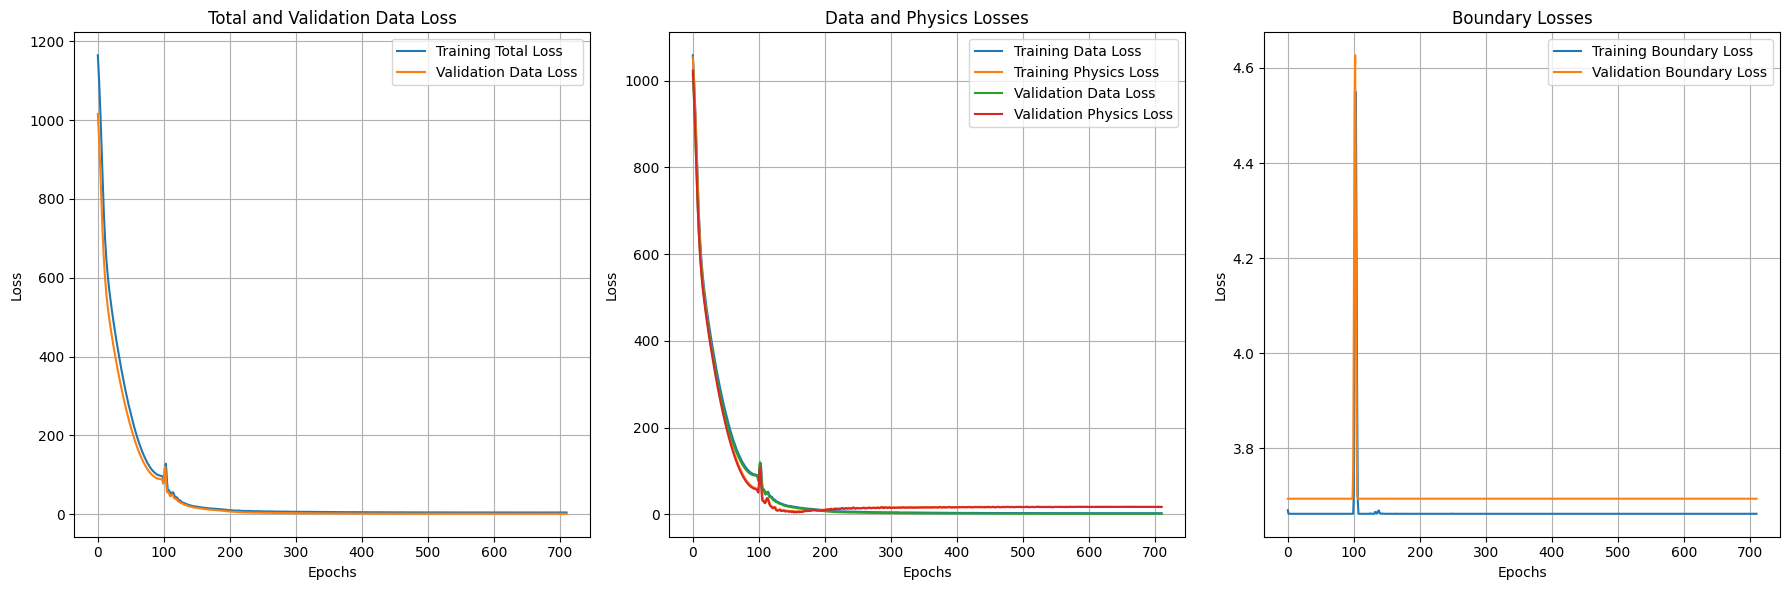

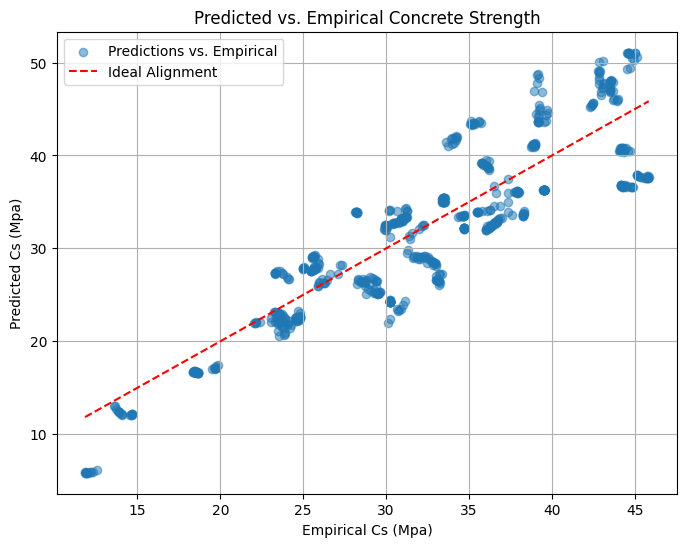

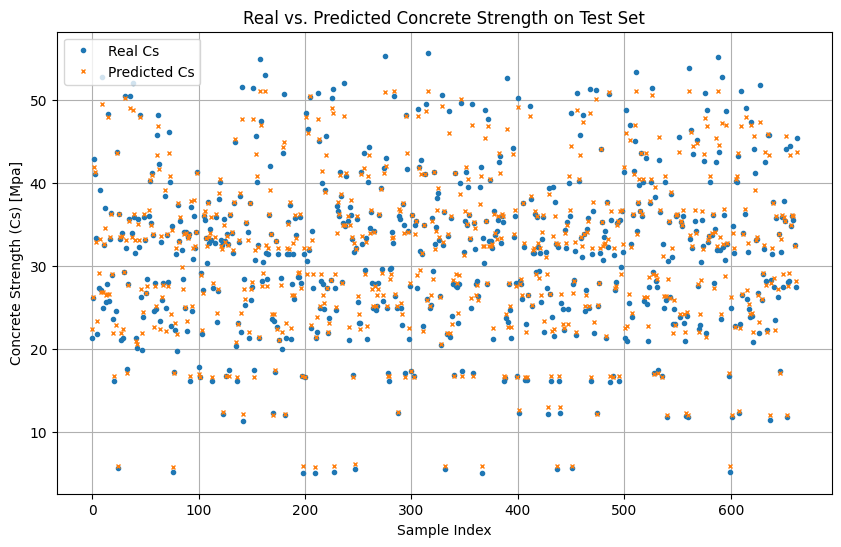

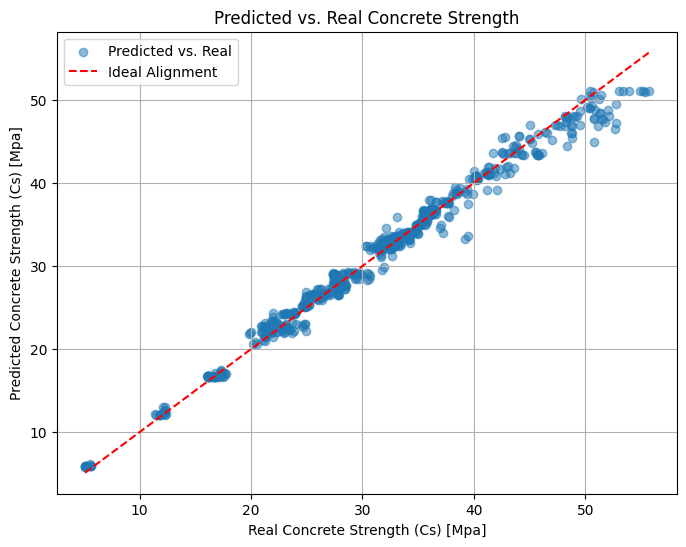

In [ ]:
# Plot Training and Validation Losses
plt.figure(figsize=(18, 6))

# Plot Total Loss and Validation Data Loss
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Training Total Loss')
plt.plot(val_losses, label='Validation Data Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Total and Validation Data Loss')
plt.legend()
plt.grid(True)

# Plot Data Loss and Physics Loss Separately
plt.subplot(1, 3, 2)
plt.plot(train_data_losses, label='Training Data Loss')
plt.plot(train_phy_losses, label='Training Physics Loss')
plt.plot(val_data_loss_list, label='Validation Data Loss')
plt.plot(val_phy_loss_list, label='Validation Physics Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Data and Physics Losses')
plt.legend()
plt.grid(True)

# Plot Boundary Losses
plt.subplot(1, 3, 3)
plt.plot(train_bnd_losses, label='Training Boundary Loss')
plt.plot(val_bnd_loss_list, label='Validation Boundary Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Boundary Losses')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Plot Predicted vs. Empirical Cs
with torch.no_grad():
    predictions = test_outputs.cpu().numpy()
    # Reconstruct Original Features from Scaled Values for Empirical Equation
    # Assuming the empirical equation uses unscaled features
    features_unscaled = scaler.inverse_transform(
        X_test[['Curing_age_(days)', 'UPV_(m/s)', 'Er_(ohm-cm)']].values
    )
    age_unscaled = features_unscaled[:, 0]
    UPV_unscaled = features_unscaled[:, 1]
    ER_unscaled = features_unscaled[:, 2]

    # Compute Empirical Cs
    empirical_Cs = (
        A * np.log(age_unscaled + B) +
        C * np.exp(D * (UPV_unscaled / 1000)) +
        F * np.log(ER_unscaled + 1e-6)  # Adding epsilon to prevent log(0)
    )

    # Plot Predicted vs. Empirical Cs
    plt.figure(figsize=(8, 6))
    plt.scatter(empirical_Cs, predictions, alpha=0.5, label='Predictions vs. Empirical')
    plt.plot([empirical_Cs.min(), empirical_Cs.max()],
             [empirical_Cs.min(), empirical_Cs.max()], 'r--', label='Ideal Alignment')
    plt.xlabel('Empirical Cs (Mpa)')
    plt.ylabel('Predicted Cs (Mpa)')
    plt.title('Predicted vs. Empirical Concrete Strength')
    plt.legend()
    plt.grid(True)
    plt.show()

# Additional Visualization: Real vs Predicted Cs on Test Set
plt.figure(figsize=(10, 6))
plt.plot(y_test_np, label='Real Cs', marker='o', linestyle='None', markersize=3)
plt.plot(test_pred_np, label='Predicted Cs', marker='x', linestyle='None', markersize=3)
plt.xlabel('Sample Index')
plt.ylabel('Concrete Strength (Cs) [Mpa]')
plt.title('Real vs. Predicted Concrete Strength on Test Set')
plt.legend()
plt.grid(True)
plt.show()

# test_pred_np: Predicted Concrete Strength values from the model

plt.figure(figsize=(8, 6))
plt.scatter(y_test_np, test_pred_np, alpha=0.5, label='Predicted vs. Real')
plt.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], 'r--', label='Ideal Alignment')
plt.xlabel('Real Concrete Strength (Cs) [Mpa]')
plt.ylabel('Predicted Concrete Strength (Cs) [Mpa]')
plt.title('Predicted vs. Real Concrete Strength')
plt.legend()
plt.grid(True)
plt.show()


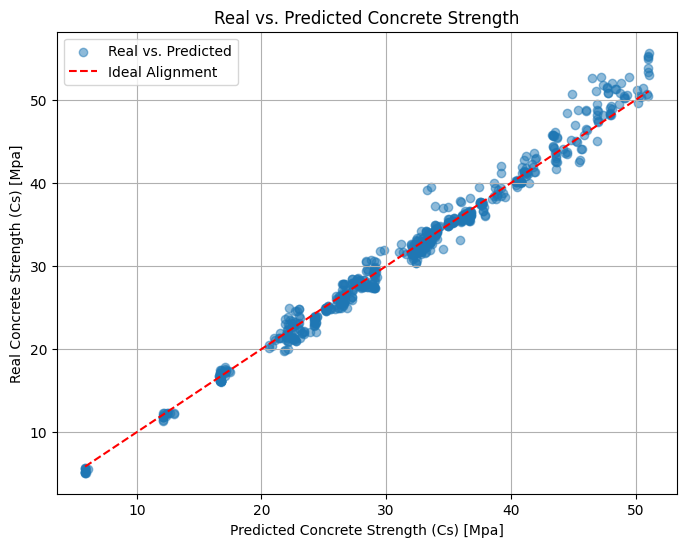

In [ ]:
plt.figure(figsize=(8, 6))
# Scatter plot with Predicted on x-axis and Real on y-axis
plt.scatter(test_pred_np, y_test_np, alpha=0.5, label='Real vs. Predicted') # Swap variables here
plt.plot([test_pred_np.min(), test_pred_np.max()], [test_pred_np.min(), test_pred_np.max()], 'r--', label='Ideal Alignment')
# Update x-axis label
plt.xlabel('Predicted Concrete Strength (Cs) [Mpa]') # Update x-axis label
# Update y-axis label
plt.ylabel('Real Concrete Strength (Cs) [Mpa]') # Update y-axis label
plt.title('Real vs. Predicted Concrete Strength') # Update title (optional)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(data.head())

   Type_of_aggregates  Curing_age_(days)  Cs_(Mpa)  Er_(ohm-cm)  UPV_(m/s)
0                   2          -1.124258    5.2154    -0.301336  -2.439777
1                   2          -1.124258    5.1528    -0.273830  -2.479605
2                   2          -1.124258    5.6877    -0.257198  -2.458265
3                   2          -1.124258    5.1476    -0.298070  -2.449187
4                   2          -1.124258    5.3406    -0.301336  -2.495933


In [ ]:
# Mount Google Drive to Colab
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Define the path in Google Drive to save the model, including the filename
model_path = '/content/drive/MyDrive/application of AI in civil engineering/concrete_strength_model.pth'  # Added filename

# Save the trained model to Google Drive
torch.save(model.state_dict(), model_path)

print(f"Model saved successfully to {model_path}")

Model saved successfully to /content/drive/MyDrive/application of AI in civil engineering/concrete_strength_model.pth


In [ ]:
# Reload the model architecture
loaded_model = ConcreteStrengthANN(input_size).to(device)

# Load the saved weights into the model
loaded_model.load_state_dict(torch.load(model_path, map_location=device))

# Set the model to evaluation mode
loaded_model.eval()
print("Model loaded successfully and ready for predictions.")


Model loaded successfully and ready for predictions.


<ipython-input-48-dc4b29280aa1>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(model_path, map_location=device))


In [ ]:
import random

# ... (previous code for loading model and scaler) ...

num_samples = 15  # Number of random sets to generate

# Feature Ranges (Adjust according to your dataset)
age_range = (1, 365)
UPV_range = (2000, 5000)
ER_range = (10, 100)
type_of_aggregates_range = (0, 1)  # Assuming 0 or 1 for categories

# Store Results
results = []

for i in range(num_samples):
    # 1. Generate Random Input Values
    age = random.uniform(age_range[0], age_range[1])
    UPV = random.uniform(UPV_range[0], UPV_range[1])
    ER = random.uniform(ER_range[0], ER_range[1])
    type_of_aggregates = random.randint(type_of_aggregates_range[0], type_of_aggregates_range[1])

    # 2. Create a DataFrame for the Input Sample
    input_data = pd.DataFrame({
        'Curing_age_(days)': [age],
        'UPV_(m/s)': [UPV],
        'Er_(ohm-cm)': [ER],
        'Type_of_aggregates': [type_of_aggregates]
    })

    # 3. Preprocess the Input Data (Scaling)
    input_data[numerical_features] = scaler.transform(input_data[numerical_features])

    # 4. Convert to Tensor and Move to Device
    input_tensor = torch.tensor(input_data.values, dtype=torch.float32).to(device)

    # 5. Get Prediction
    with torch.no_grad():
        prediction = loaded_model(input_tensor)

    # 6. Store Results
    results.append({
        'Inputs': input_data.iloc[0].to_dict(),  # Store original unscaled inputs
        'Predicted_Cs': prediction.item(),
    })

# Print the Results in a Table Format
print("-" * 70)
print("{:<15} {:<15} {:<15} {:<15} {:<15}".format("Age (days)", "UPV (m/s)", "Er (ohm-cm)", "Type", "Predicted Cs (Mpa)"))
print("-" * 70)
for result in results:
    inputs = result['Inputs']
    print("{:<15.2f} {:<15.2f} {:<15.2f} {:<15} {:<15.4f}".format(
        inputs['Curing_age_(days)'], inputs['UPV_(m/s)'], inputs['Er_(ohm-cm)'],
        inputs['Type_of_aggregates'], result['Predicted_Cs']
    ))
print("-" * 70)

----------------------------------------------------------------------
Age (days)      UPV (m/s)       Er (ohm-cm)     Type            Predicted Cs (Mpa)
----------------------------------------------------------------------
8.46            1.69            3.42            0.0             35.4119        
1.27            1.94            8.41            0.0             9.3805         
7.80            0.06            12.79           0.0             -15.7463       
8.83            0.63            4.83            1.0             33.1949        
5.56            -1.78           12.24           0.0             -23.6845       
0.64            -2.43           24.01           1.0             -25.7390       
7.49            -0.74           29.58           1.0             -23.3797       
7.35            0.92            4.90            1.0             33.9814        
8.00            -2.69           29.78           1.0             -24.2773       
0.80            -2.79           9.61            1.0    

In [ ]:
import random

# ... (Your existing code for loading the model and scaler) ...

# 1. Get 15 random samples from the original dataset
num_samples = 15
random_samples = data.sample(n=num_samples, random_state=42)  # Use random_state for reproducibility

# 2. Prepare the input data for prediction
X_random = random_samples.drop('Cs_(Mpa)', axis=1)
y_random = random_samples['Cs_(Mpa)']

# 3. Store the original input values before scaling
X_random_original = X_random.copy()  # Keep a copy of the unscaled data

# 4. Preprocess the input data (Scaling)
X_random[numerical_features] = scaler.transform(X_random[numerical_features])  # Use the original scaler

# ... (Rest of the code remains the same, but use X_random_original for printing) ...

# 7. Print or Display the Results with Original Input Parameters
print("-" * 90)
print("{:<15} {:<15} {:<15} {:<15} {:<15} {:<15}".format(
    "Age (days)", "UPV (m/s)", "Er (ohm-cm)", "Type", "Real Cs (Mpa)", "Predicted Cs (Mpa)"
))
print("-" * 90)

for i in range(num_samples):
    input_values = X_random_original.iloc[i].to_dict()  # Get original input values
    print("{:<15.2f} {:<15.2f} {:<15.2f} {:<15} {:<15.4f} {:<15.4f}".format(
        input_values['Curing_age_(days)'],
        input_values['UPV_(m/s)'],
        input_values['Er_(ohm-cm)'],
        input_values['Type_of_aggregates'],
        real_values[i],
        predicted_values[i]
    ))

print("-" * 90)

------------------------------------------------------------------------------------------
Age (days)      UPV (m/s)       Er (ohm-cm)     Type            Real Cs (Mpa)   Predicted Cs (Mpa)
------------------------------------------------------------------------------------------
-0.79           -0.92           -0.24           2.0             21.3143         29.2950        
-0.01           -0.12           -0.50           2.0             26.1137         30.1529        
-0.01           0.26            0.57            0.0             42.9158         33.6811        
-0.01           0.19            0.42            0.0             41.1175         34.0040        
-0.79           1.13            -0.22           1.0             33.3534         31.7866        
-0.79           1.11            -0.46           0.0             21.8221         35.6435        
-0.01           -0.50           -0.89           2.0             27.3379         31.1254        
-0.37           1.38            0.21           